# DispersionWelle
The program demonstrates dispersion via the difference between group velocity and phase velocity.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert

## Parameters

Wave numbers:

$$k = \frac{2\pi}{\lambda}$$

Angular frequency:
$$\omega = v_{ph} k$$

In [2]:
# normal dispersion (selection)
lambda1 = 0.95                                       # Wavelength 1 in meters
lambda2 = 1.05                                       # Wavelength 2 in meters
lambda_ = (lambda1 + lambda2)/2                      # Mean wavelength in meters
vph1 = 0.975                                         # Phase velocity 1 in m/s
vph2 = 1.025                                         # Phase velocity 2 in m/s

# Anomalous dispersion (alternative selection)
# lambda1 = 0.95                                     # Wavelength 1 in meters
# lambda2 = 1.05                                     # Wavelength 2 in meters
# lambda_ = (lambda1 + lambda2)/2                    # Mean wavelength in meters
# vph1 = 1.025                                       # Phase velocity 1 in m/s
# vph2 = 0.975                                       # Phase velocity 2 in m/s

# Wave numbers and angular frequencies
k0 = 2*np.pi/lambda_                                 # Wave number in 1/m
k1 = 2*np.pi/lambda1                                 # Wave number 1 in 1/m
k2 = 2*np.pi/lambda2                                 # Wave number 2 in 1/m
omega1 = vph1*k1                                     # Angular frequency 1 in 1/s
omega2 = vph2*k2                                     # Angular frequency 2 in 1/s

vph = (vph1+vph2)/2                                  # Approximate average phase velocity
vgr = (omega1-omega2)/(k1-k2)                        # Approximate group velocity
vgr2 = vph - lambda_*(vph1-vph2)/(lambda1-lambda2)   # Approximate group-phase velocity

## Spatial and Time Grid

In [3]:
xend = 20
xsteps = 400
tend = 40
tsteps = 40
x = np.linspace(0,xend,xsteps)
t = np.linspace(0, tend, tsteps)
deltax = xend/xsteps
deltat = t[1] - t[0]
X,T = np.meshgrid(x,t,indexing='ij')

## Two Waves Propagating in the Same Direction
$$\psi(x,t) = \cos(kx-\omega t)$$

In [4]:
psi1 = np.cos(k1*x[:,None] - omega1*t[None,:])
psi2 = np.cos(k2*x[:,None] - omega2*t[None,:])
psig = psi1 + psi2

## Envelope Function

In [5]:
def envelope(signal):
    analytic = hilbert(signal)
    return np.abs(analytic), -np.abs(analytic)

## Wave Pattern at Two Different Times

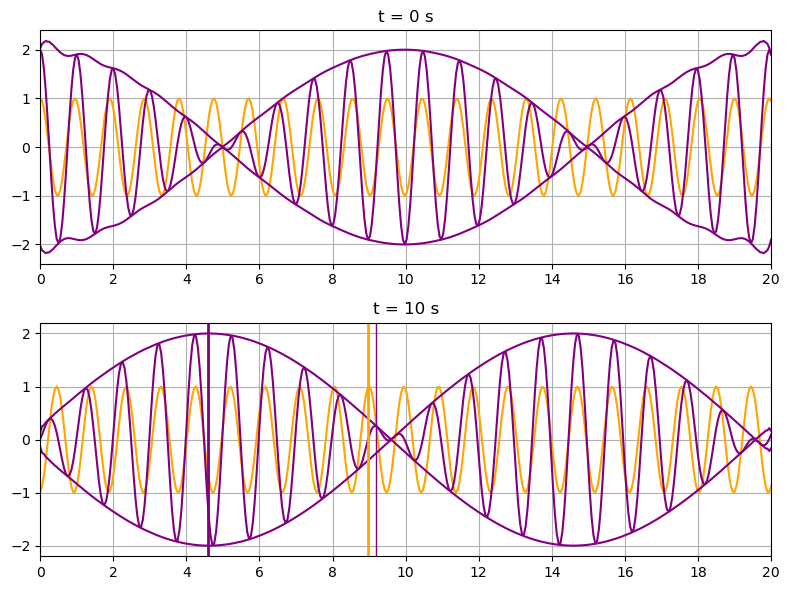

In [6]:
plt.figure(figsize=(8,6))

# Colors
color_träger = 'orange' 
color_env = 'purple'    

# First time snapshot
tmess = 0
kmess = np.argmin(np.abs(t - tmess))
plt.subplot(2,1,1)
plt.plot(x, psi1[:,kmess], color=color_träger)      
plt.plot(x, psig[:,kmess], color=color_env)          
up, lo = envelope(psig[:,kmess])
plt.plot(x, up, color=color_env)
plt.plot(x, lo, color=color_env)
plt.grid()
plt.title(f"t = {tmess} s")
plt.xlim(0, 20)  
plt.xticks(np.arange(0, 21, 2))

# Second time snapshot
tmess = 10
#kmess = int(tmess/deltat)
#neu
tmess = 10
kmess = int(tmess / deltat)
plt.subplot(2,1,2)
plt.plot(x, psi1[:,kmess], color=color_träger)       
plt.plot(x, psig[:,kmess], color=color_env)          
up, lo = envelope(psig[:,kmess])
plt.plot(x, up, color=color_env)
plt.plot(x, lo, color=color_env)
mup = np.argmax(up)
plt.axvline(x=mup*deltax, color=color_env, linewidth=2)
plt.axvline(x=vph/vgr*mup*deltax, color=color_env, linewidth=1)
plt.axvline(x=vph1/vgr*mup*deltax, color=color_träger, linewidth=2)
plt.grid()
plt.title(f"t = {tmess} s")
plt.xlim(0, 20)
plt.xticks(np.arange(0, 21, 2))

plt.tight_layout()
plt.show()

## Wave Packet
$$\psi(x,t)=\sum_n A_n \cos(k_n x-\omega_n t)$$

In [7]:
vph0 = 1
vd = -0.4
lambda0 = 1.0
kw0 = 2*np.pi/lambda0
Nmax = 101
n = np.arange(Nmax)
lambda_n = lambda0 + 0.2*(n-Nmax)/(Nmax-1)
kw = 2*np.pi/lambda_n
vph_n = vph0 + vd*(np.abs(kw)-kw0)/kw0
omega = vph_n*kw
A = np.exp(-((n-Nmax)/(Nmax-1))**2/4)

## Vectorized Wave Packet Calculation

In [8]:
kw = kw[:,None,None]
omega = omega[:,None,None]
A = A[:,None,None]
psi_wp = np.sum(A*np.cos(kw*X - omega*T),axis=0)

## Simulation of Wave Packet Propagation

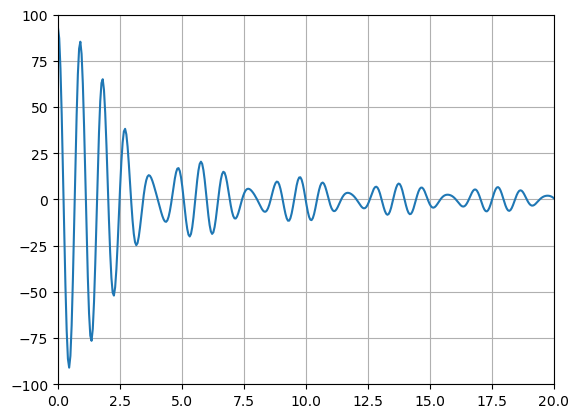

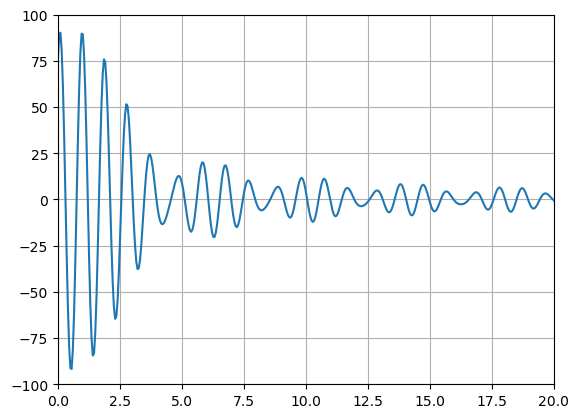

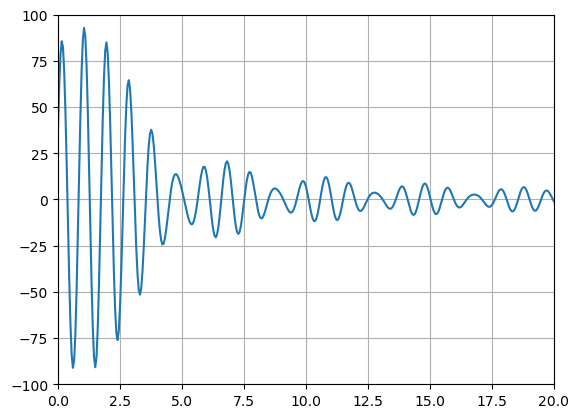

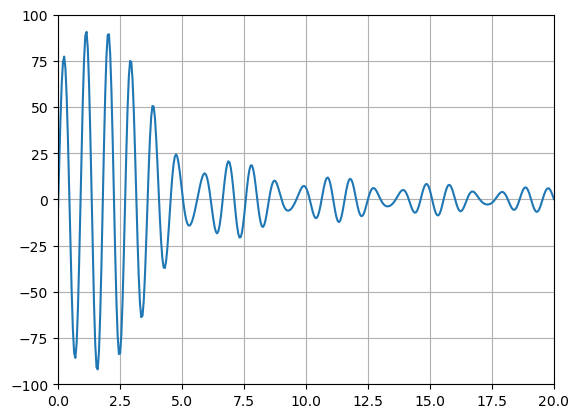

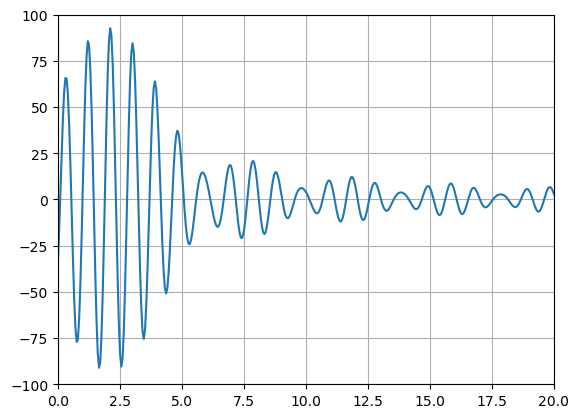

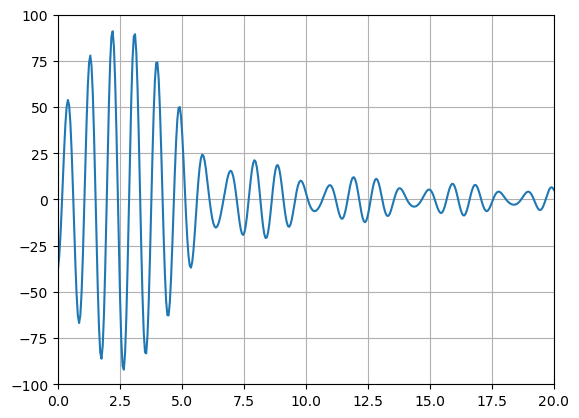

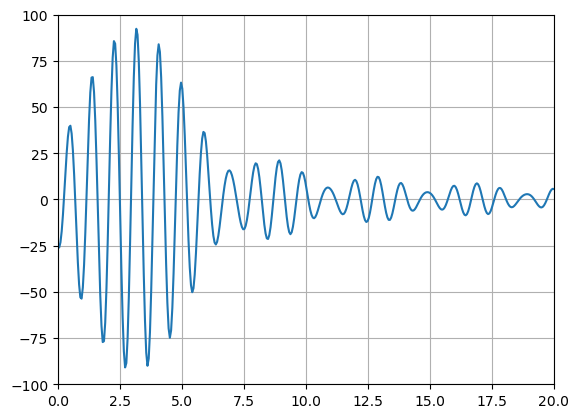

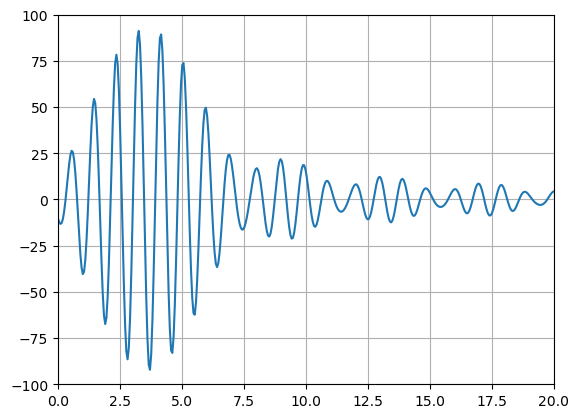

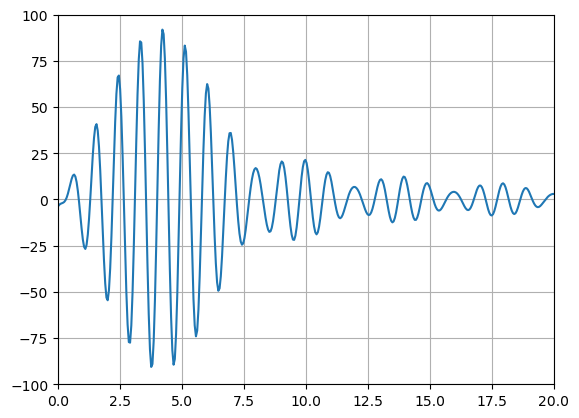

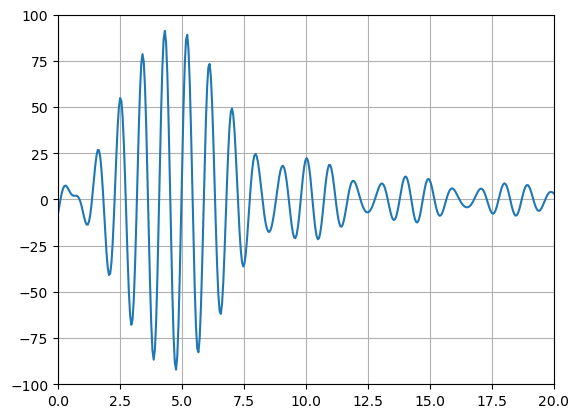

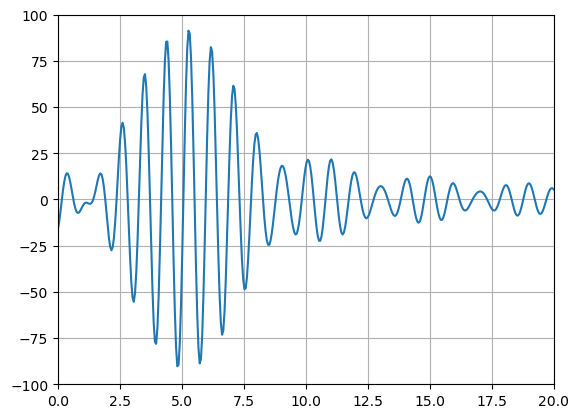

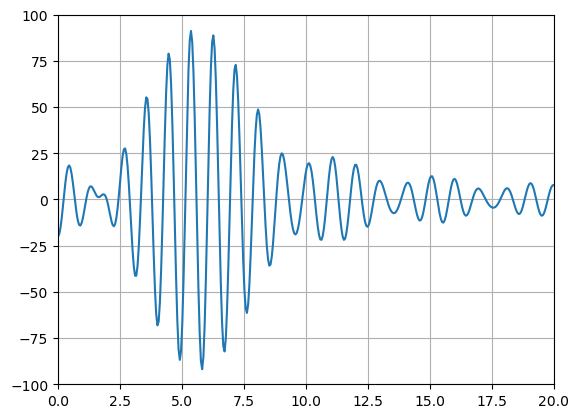

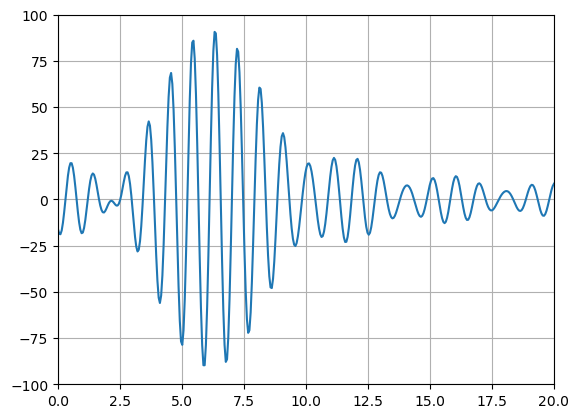

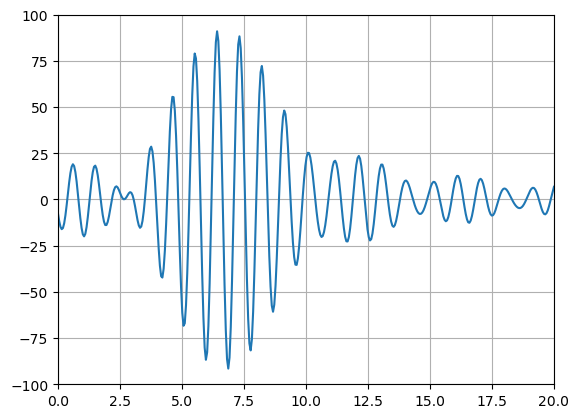

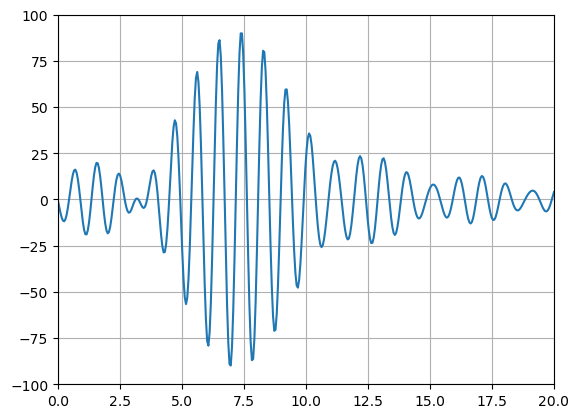

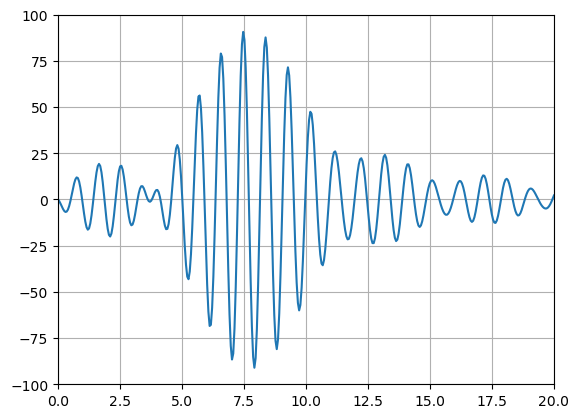

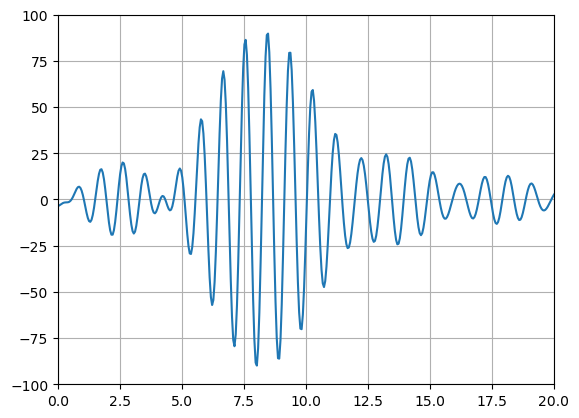

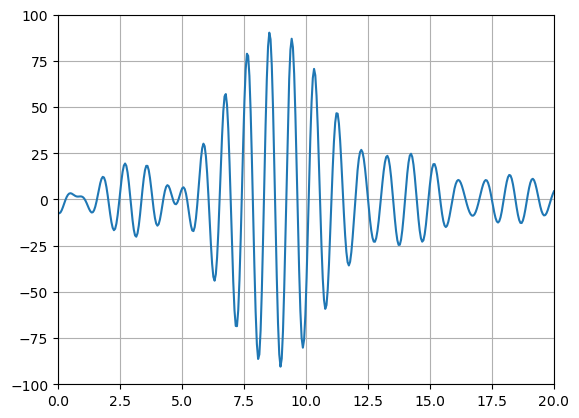

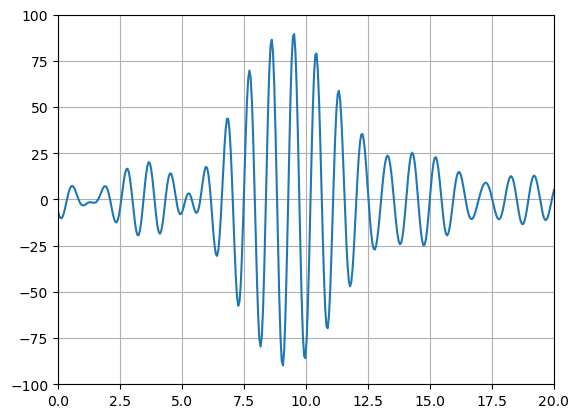

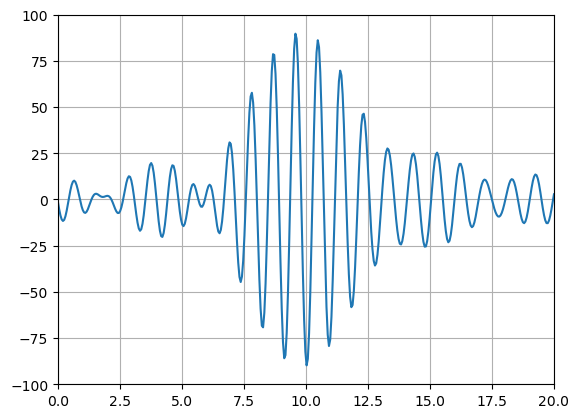

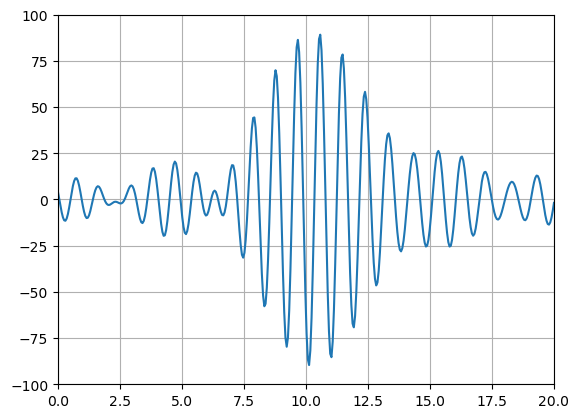

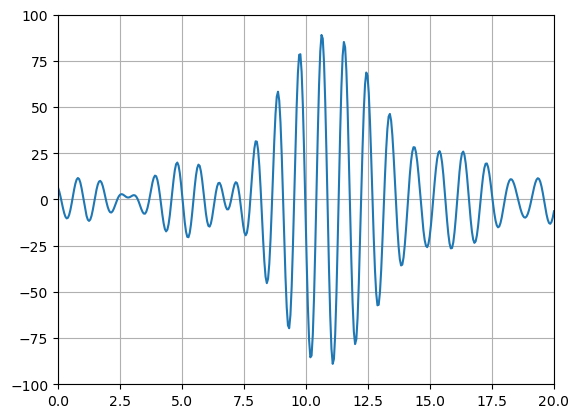

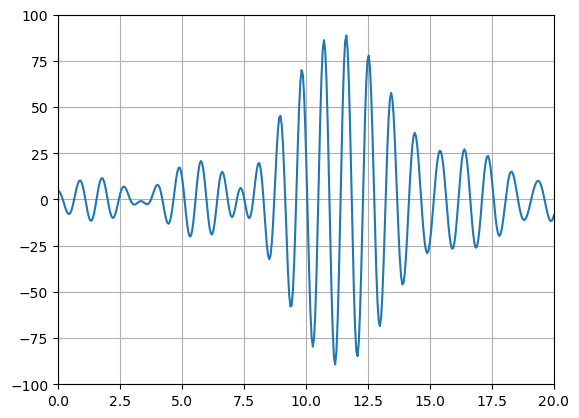

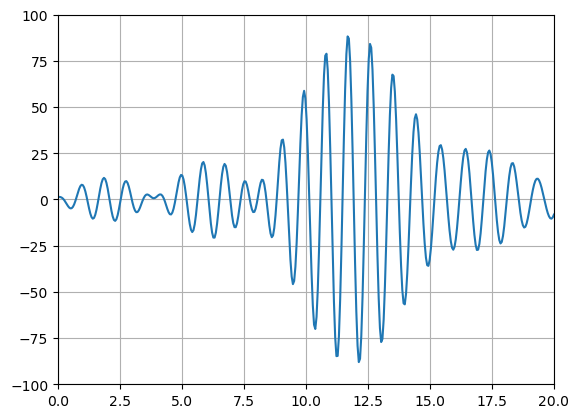

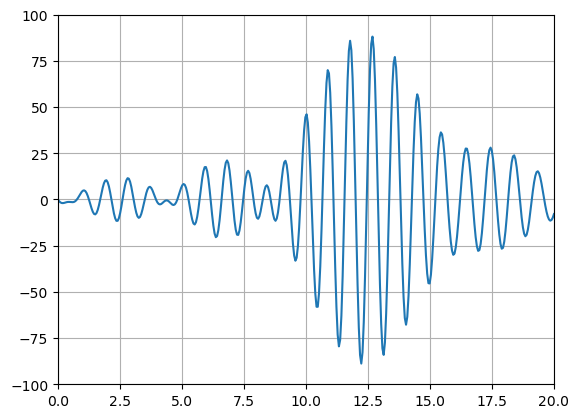

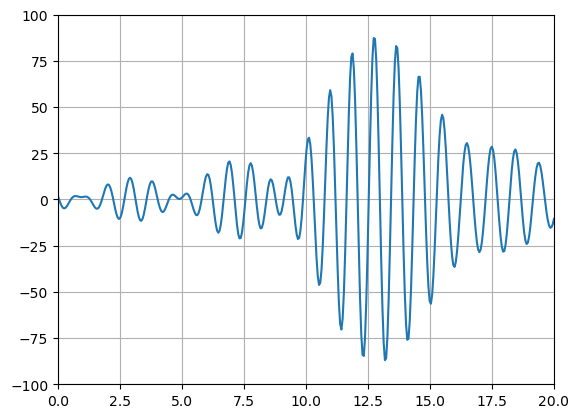

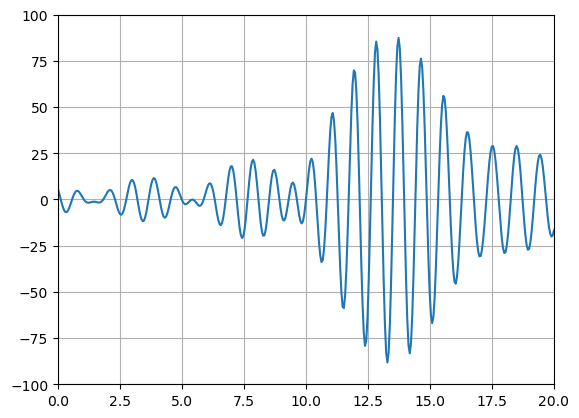

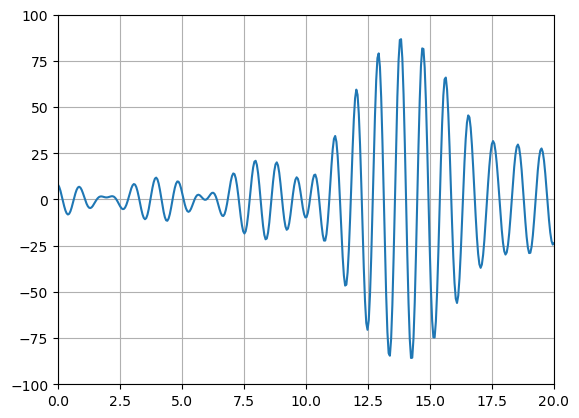

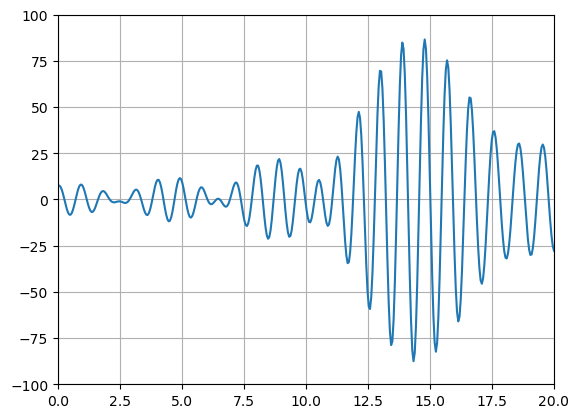

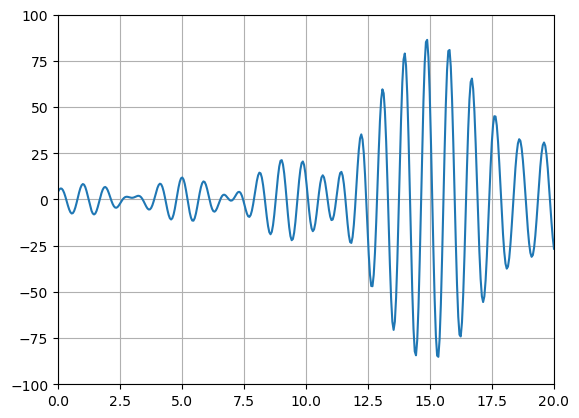

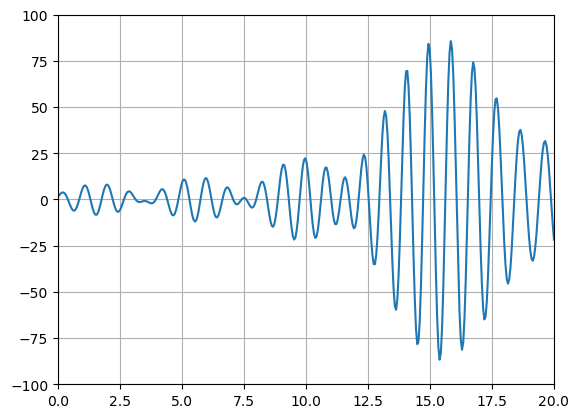

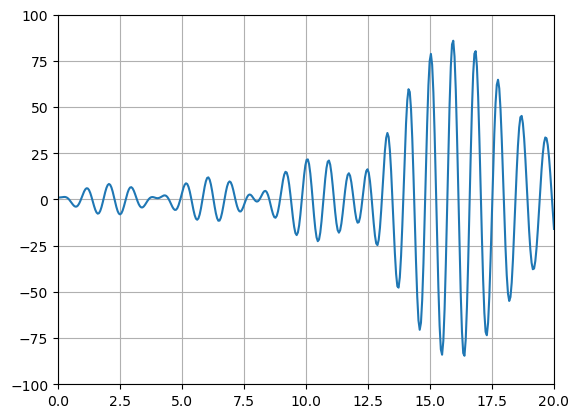

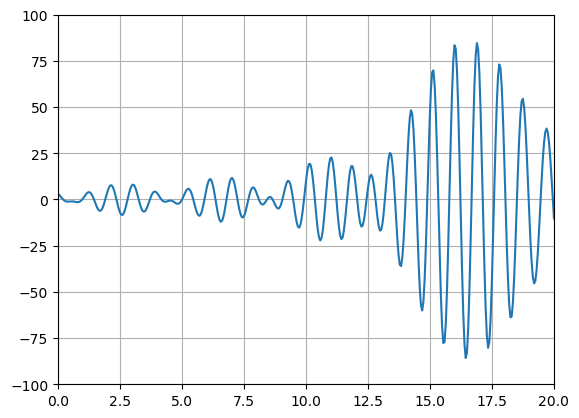

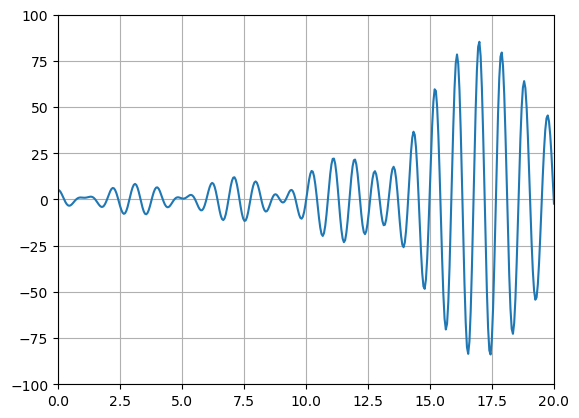

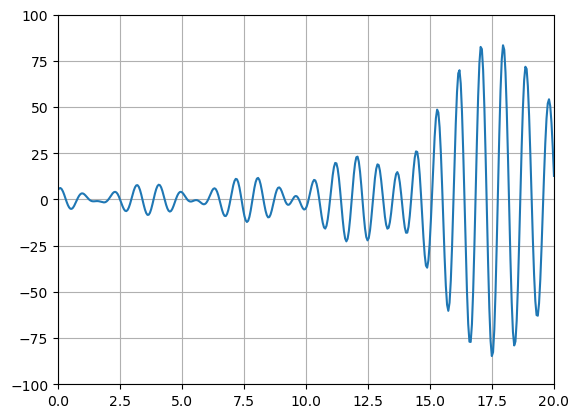

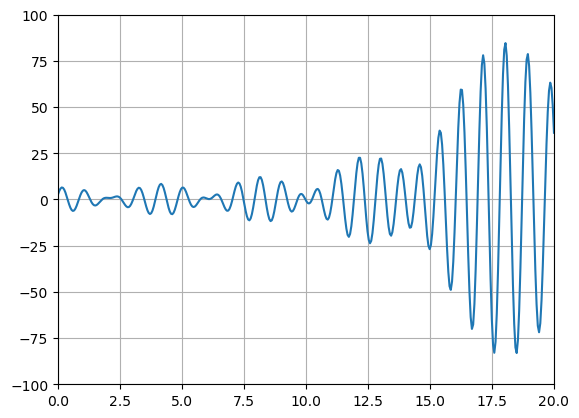

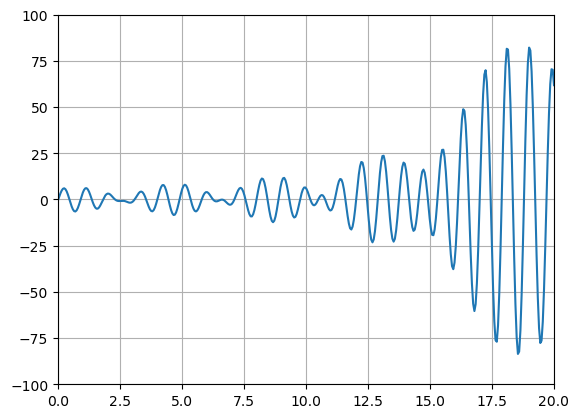

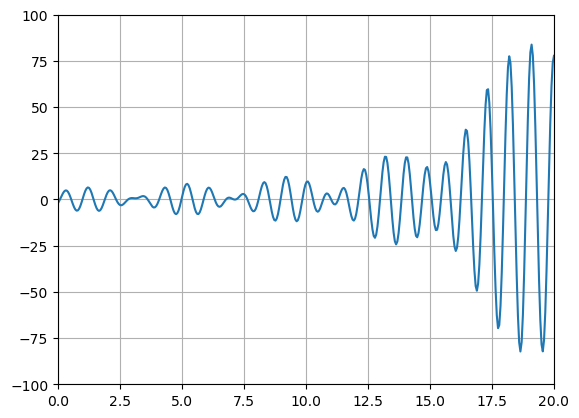

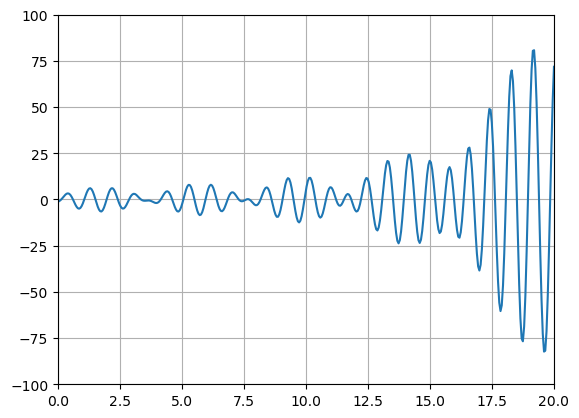

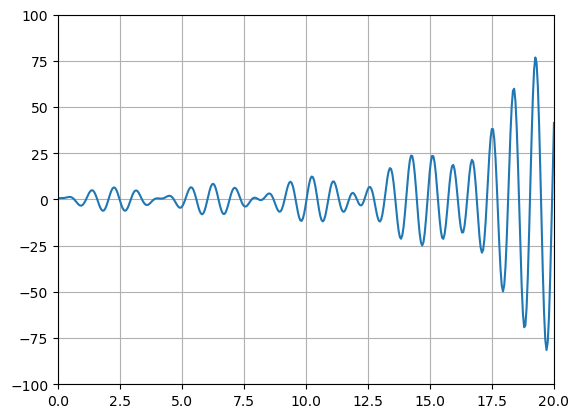

In [9]:
plt.figure()
for k in range(len(t)):
    plt.clf()
    plt.plot(x,psi_wp[:,k])
    plt.xlim(0,20)
    plt.ylim(-100,100)
    plt.grid()
    plt.pause(0.04)
plt.show()

## Wave Packet at Two Different Times

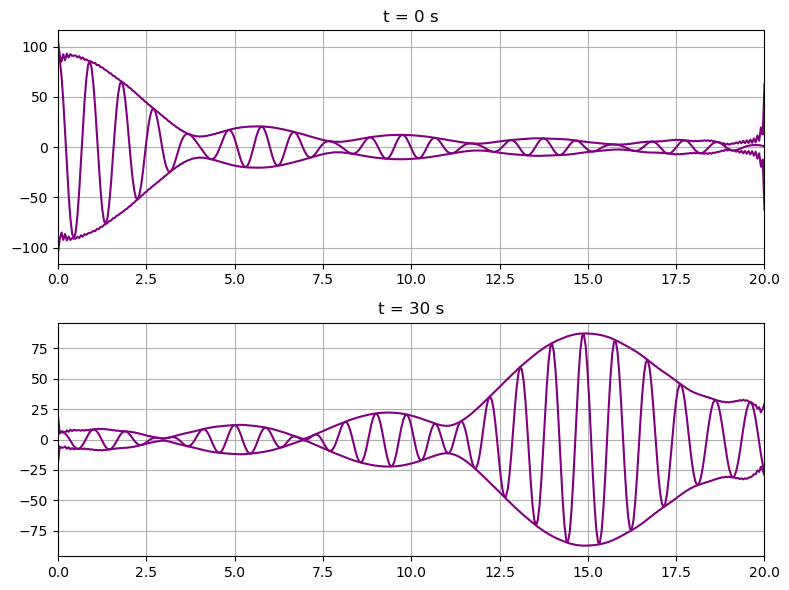

In [10]:
plt.figure(figsize=(8,6))

# First time snapshot
tmess = 0
kmess = 0
plt.subplot(2,1,1)
plt.plot(x, psi_wp[:,kmess], color=color_env)
up, lo = envelope(psi_wp[:,kmess])
plt.plot(x, up, color=color_env)
plt.plot(x, lo, color=color_env)
plt.title(f"t = {tmess} s")
plt.grid()
plt.xlim(0, 20)

# Second time snapshot
tmess = 30
kmess = int(tmess/deltat)
plt.subplot(2,1,2)
plt.plot(x, psi_wp[:,kmess], color=color_env)
up, lo = envelope(psi_wp[:,kmess])
plt.plot(x, up, color=color_env)
plt.plot(x, lo, color=color_env)
plt.title(f"t = {tmess} s")
plt.grid()
plt.xlim(0, 20)

plt.tight_layout()
plt.show()